In [1]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import os
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data_lines_with_vals.csv")

In [3]:
mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


# A few SFRS
t_array = np.linspace(0.0001,14,int(1e2))
def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

In [4]:
def centered_array(center, step, num):
    shift_steps = (num - 1) / 2
    start = center - (shift_steps * step)
    stop = center + (shift_steps * step)
    
    arr = np.linspace(start, stop, num)
    
    # Only keep strictly positive values
    positive_arr = []
    for val in arr:
        if val > 0:
            positive_arr.append(val)
            
    return np.array(positive_arr)

In [5]:
def get_sampled_gals(t_array, params, alpha_cc, alpha_Ia, g_cc, g_ratio):
        gals_list = []
        for eta, tau_star, sfr in params:
            gals_list.append(evo.Galaxy(
                t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                eta=eta, Upsilon=1, yields_ref="W2024,moreFe",
                g_cc_Mn=g_cc, g_ratio_Mn=g_ratio,
                alpha_cc_Mn=alpha_cc, alpha_Ia_Mn=alpha_Ia
            ))
        return gals_list

In [6]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []
    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            crossed = False
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    crossed = True
                    break
            if not crossed:
                endpoints.append(-1) # Critical fix to maintain 1:1 mapping with galaxies
        endpoints_gals.append(np.array(endpoints))
    return endpoints_gals

In [7]:
def make_models(param_to_optimize, t_array, sfrs, alpha_cc_init, alpha_Ia_init, g_cc_init, g_ratio_init, etas, tau_stars,
                grid_size, grid_len, iter, save_dir="models", save="on"):

    alpha_ccs = centered_array(center = alpha_cc_init, step = grid_size, num = grid_len)
    alpha_Ias = centered_array(center = alpha_Ia_init, step = grid_size, num = grid_len)
    g_ccs = centered_array(center=g_cc_init, step = grid_size, num = grid_len)
    g_ratios = centered_array(center = g_ratio_init, step = grid_size, num = grid_len)

    if param_to_optimize == "alpha_cc":
        met_dep_param_to_fit = alpha_ccs
        print("alpha_ccs = ", met_dep_param_to_fit)
    elif param_to_optimize == "alpha_Ia":
        met_dep_param_to_fit = alpha_Ias
        print("alpha_Ias = ", met_dep_param_to_fit)
    elif param_to_optimize == "g_cc":
        met_dep_param_to_fit = g_ccs
        print("g_ccs = ", met_dep_param_to_fit)
    elif param_to_optimize == "g_ratio":
        met_dep_param_to_fit = g_ratios
        print("g_ratios = ", met_dep_param_to_fit)

    n_gals = len(etas) * len(tau_stars) * len(sfrs)
    print(f"n_gals in each {param_to_optimize} = ", n_gals)
    print("n_gals total = ", n_gals * len(alpha_ccs))

    all_params = list(itertools.product(etas, tau_stars, sfrs))
    random.seed(42)
    # In case we want to sample a few and not use all of them
    #sampled_params = random.sample(all_params, 100)

    # 2. Iterate and build models
    for current_val in met_dep_param_to_fit:
        # Set all to initial defaults first
        a_cc = alpha_cc_init
        a_Ia = alpha_Ia_init
        g_cc = g_cc_init
        g_rat = g_ratio_init

        # Override only the parameter currently being optimized
        if param_to_optimize == "alpha_cc":
            a_cc = current_val
        elif param_to_optimize == "alpha_Ia":
            a_Ia = current_val
        elif param_to_optimize == "g_cc":
            g_cc = current_val
        elif param_to_optimize == "g_ratio":
            g_rat = current_val

        # Call the function once per loop iteration
        gals_list = get_sampled_gals(t_array=t_array, params=all_params, 
            alpha_cc=a_cc, alpha_Ia=a_Ia, g_cc=g_cc, g_ratio=g_rat)

        gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)


        # 2. Extract data
        extracted_data = []

        for i in range(len(mg_h_big_bin_centers)):
            idxs = gals_endpoints[i]
            current_mg_h = mg_h_big_bin_centers[i]

            for gal, idx in zip(gals_list, idxs):
                sfr = gal.m_g_array
                if np.allclose(sfr, m_g_array_const):
                    sfr_label = "const SFR"
                elif np.allclose(sfr, m_g_array_exp):
                    sfr_label = "exp SFR"
                elif np.allclose(sfr, m_g_array_rise_fall_1):
                    sfr_label = "rise+fall  1"
                elif np.allclose(sfr, m_g_array_rise_fall_2):
                    sfr_label = "rise+fall  2"
                elif np.allclose(sfr, m_g_array_rise_fall_3):
                    sfr_label = "rise+fall  3"
                else:
                    sfr_label = "unknown SFR"

                if idx != -1:  
                    extracted_data.append({
                        'mn_fe': gal.Mn_Fe[idx],
                        'mn_mg': gal.Mn_Mg[idx],
                        'fe_mg': gal.Fe_Mg[idx],
                        'fe_h': gal.Fe_H[idx],
                        'mg_h': gal.Mg_H[idx],
                        'mn_h': gal.Mn_H[idx],
                        't': gal.t[idx],
                        'tau_star': gal.tau_star_arr[idx],
                        'eta': gal.eta_arr[idx],
                        'sfr': sfr_label,
                        'alpha_cc': gal.alpha_cc_Mn,
                        'alpha_Ia': gal.alpha_Ia_Mn,
                        'g_cc': gal.g_cc_Mn,
                        'g_ratio': gal.g_ratio_Mn,
                        'Upsilon': gal.Upsilon,
                        'mg_h_bin': current_mg_h
                    })

        df_endpoints = pd.DataFrame(extracted_data)
        df_endpoints = pd.DataFrame(extracted_data)
        if save == "on":
            os.makedirs(save_dir, exist_ok=True)
            df_endpoints.to_csv(os.path.join(save_dir, f"{param_to_optimize}_iter{iter}_{current_val:.4f}.csv"), index=False)



In [8]:
sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1]
alpha_cc_init = 0.5
alpha_Ia_init = 0.6
g_cc_init = 0.4
g_ratio_init = 2
etas = [0, 0.1, 0.2, 0.5, 1, 2]
tau_stars = [1, 2, 3, 4, 5, 10]

grid_size = 0.1
grid_len = 5
iter = 0

In [9]:
def find_best_model(filepath_list, param, iter, folder_path, data=data):
    chi2_results = []
    for file in filepath_list:
        model_df = pd.read_csv(file)
        chi2_sum_per_bin = []
        for mg_h_bin in model_df['mg_h_bin'].unique():
            model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
            data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
            expected_mn_fe = (model_subset['fe_mg'] * data_subset['slope_mn_fe'].iloc[0]) + data_subset['intercept_mn_fe'].iloc[0]
            model_mn_fe = model_subset['mn_fe']
            subset_res_sq = (model_mn_fe - expected_mn_fe)**2
            n_points = len(subset_res_sq)
            chi2_sum_per_bin.append(subset_res_sq.sum())

        chi_2_sum = sum(chi2_sum_per_bin)
        chi2_results.append({'file': file,
                            'alpha_cc': model_df['alpha_cc'].iloc[0],
                            'alpha_Ia': model_df['alpha_Ia'].iloc[0],
                            'g_cc': model_df['g_cc'].iloc[0],
                            'g_ratio': model_df['g_ratio'].iloc[0],
                            'Upsilon': model_df['Upsilon'].iloc[0],
                            'chi_2_sum': chi_2_sum,
                            'reduced_chi2': chi_2_sum/n_points,
                            'n_points': n_points 
                            })
            
    results_df = pd.DataFrame(chi2_results).reset_index(drop=True)
    results_df.to_csv(folder_path+f"chi_2_results_{param}_iter_{iter}.csv")
    min_chi_2 = min(results_df['chi_2_sum'])
    best_result = results_df[results_df['chi_2_sum'] == min_chi_2]
    return (best_result)

In [10]:
folder_path = "models_make_script_again_loop_5_iters/"

filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter_0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)

In [11]:
plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

<Figure size 2000x500 with 0 Axes>

In [12]:
plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        expected_mn_fe = data_subset['slope_mn_fe'].iloc[0] * model_subset['fe_mg'] + data_subset['intercept_mn_fe'].iloc[0]
        res = expected_mn_fe - model_subset['mn_fe']
        plt.subplot(1,5,j+1)
        plt.scatter(model_subset['fe_mg'], res, label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.axhline(0, linestyle = '--', color = 'gray')
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe] residuals")
            plt.legend()

plt.tight_layout()
plt.show()

<Figure size 2000x500 with 0 Axes>

In [13]:
folder_path = "models_troubleshoot/"

filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)

In [14]:
folder_path = "models_make_script_again_loop_5_iters/"
parameters_to_fit = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]
total_iterations = 5  
iteration_results = []

current_alpha_cc = alpha_cc_init
current_alpha_Ia = alpha_Ia_init
current_g_cc = g_cc_init
current_g_ratio = g_ratio_init

for i in range(total_iterations):
    
    for param in parameters_to_fit:
        make_models(param, t_array, sfrs, 
                    alpha_cc_init=current_alpha_cc, 
                    alpha_Ia_init=current_alpha_Ia,
                    g_cc_init=current_g_cc, 
                    g_ratio_init=current_g_ratio, 
                    etas=etas, tau_stars=tau_stars,
                    grid_size=grid_size, grid_len=grid_len, 
                    iter=i, save_dir=folder_path, save="on")
        
        filepath_list = []
        for filename in os.listdir(folder_path):
            file_prefix = param + "_iter" + str(i)
            if filename.startswith(file_prefix) and filename.endswith(".csv"):
                filepath_list.append(folder_path + filename)
                
        best_model = find_best_model(filepath_list=filepath_list, param=param, iter=i, folder_path=folder_path)
        print(f"iter = {i}")
        print(f"best {param} =", best_model[param].iloc[0])

        if param == "alpha_cc":
            current_alpha_cc = best_model['alpha_cc'].iloc[0]
        if param == "alpha_Ia":
            current_alpha_Ia = best_model['alpha_Ia'].iloc[0]
        if param == "g_cc":
            current_g_cc = best_model['g_cc'].iloc[0]
        if param == "g_ratio":
            current_g_ratio = best_model['g_ratio'].iloc[0]

        iteration_results.append({'iteration': i,
                                  'best_alpha_cc': current_alpha_cc,
                                  'best_alpha_Ia': current_alpha_Ia,
                                  'best_g_cc': current_g_cc,
                                  'best_g_ratio': current_g_ratio})

iteration_results_df = pd.DataFrame(iteration_results)
iteration_results_df.to_csv(folder_path + "best_parameters_per_iteration.csv", index=False)

alpha_ccs =  [0.3 0.4 0.5 0.6 0.7]
n_gals in each alpha_cc =  108
n_gals total =  540
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.4 0.5 0.6 0.7 0.8]
n_gals in each alpha_Ia =  108
n_gals total =  540
iter = 0
best alpha_Ia = 0.5
g_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each g_cc =  108
n_gals total =  540
iter = 0
best g_cc = 0.4
g_ratios =  [1.8 1.9 2.  2.1 2.2]
n_gals in each g_ratio =  108
n_gals total =  540
iter = 0
best g_ratio = 1.8
alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  108
n_gals total =  540
iter = 1
best alpha_cc = 0.3
alpha_Ias =  [0.3 0.4 0.5 0.6 0.7]
n_gals in each alpha_Ia =  108
n_gals total =  540
iter = 1
best alpha_Ia = 0.3999999999999999
g_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each g_cc =  108
n_gals total =  540
iter = 1
best g_cc = 0.4
g_ratios =  [1.6 1.7 1.8 1.9 2. ]
n_gals in each g_ratio =  108
n_gals total =  540
iter = 1
best g_ratio = 1.7000000000000002
alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  108
n_gals total =

In [15]:
results = pd.read_csv("models_make_script_again_loop_5_iters/chi_2_results_g_ratio_iter_4.csv")

In [16]:
min_red_chi2_row = results[results['reduced_chi2'] == min(results['reduced_chi2'])]
min_red_chi2_row

,Unnamed: 0,file,alpha_cc,alpha_Ia,g_cc,g_ratio,Upsilon,chi_2_sum,reduced_chi2,n_points
2,2,models_make_script_again_loop_5_iters/g_ratio_...,0.3,0.4,0.4,1.7,1,1.112138,0.029267,38


In [17]:
min(results['reduced_chi2'])

0.0292667983095445

In [18]:
from chemevo import iterative_1D_method

In [28]:
iterative_1D_method.iterative_1D_loop(data_path="data_lines_with_vals.csv", output_path="penalty/",
                                      n_iters=5, grid_size=0.1, grid_len=5, alpha_cc_init=0.3,
                                      alpha_Ia_init=0.4, g_cc_init=0.4, g_ratio_init=1.8)

alpha_ccs =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_cc =  500
n_gals total =  2500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.1999999999999999
alpha_Ias =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_Ia =  500
n_gals total =  2000
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
bes

In [29]:
best_per_iter = pd.read_csv("penalty/best_parameters_per_iteration.csv")

In [30]:
best_per_iter

,iteration,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio
0,0,0.2,0.4,0.4,1.8
1,0,0.2,0.6,0.4,1.8
2,0,0.2,0.6,0.4,1.8
3,0,0.2,0.6,0.4,1.7
4,1,0.2,0.6,0.4,1.7
5,1,0.2,0.7,0.4,1.7
6,1,0.2,0.7,0.4,1.7
7,1,0.2,0.7,0.4,1.7
8,2,0.2,0.7,0.4,1.7
9,2,0.2,0.7,0.4,1.7


In [31]:
folder_path = "penalty/"

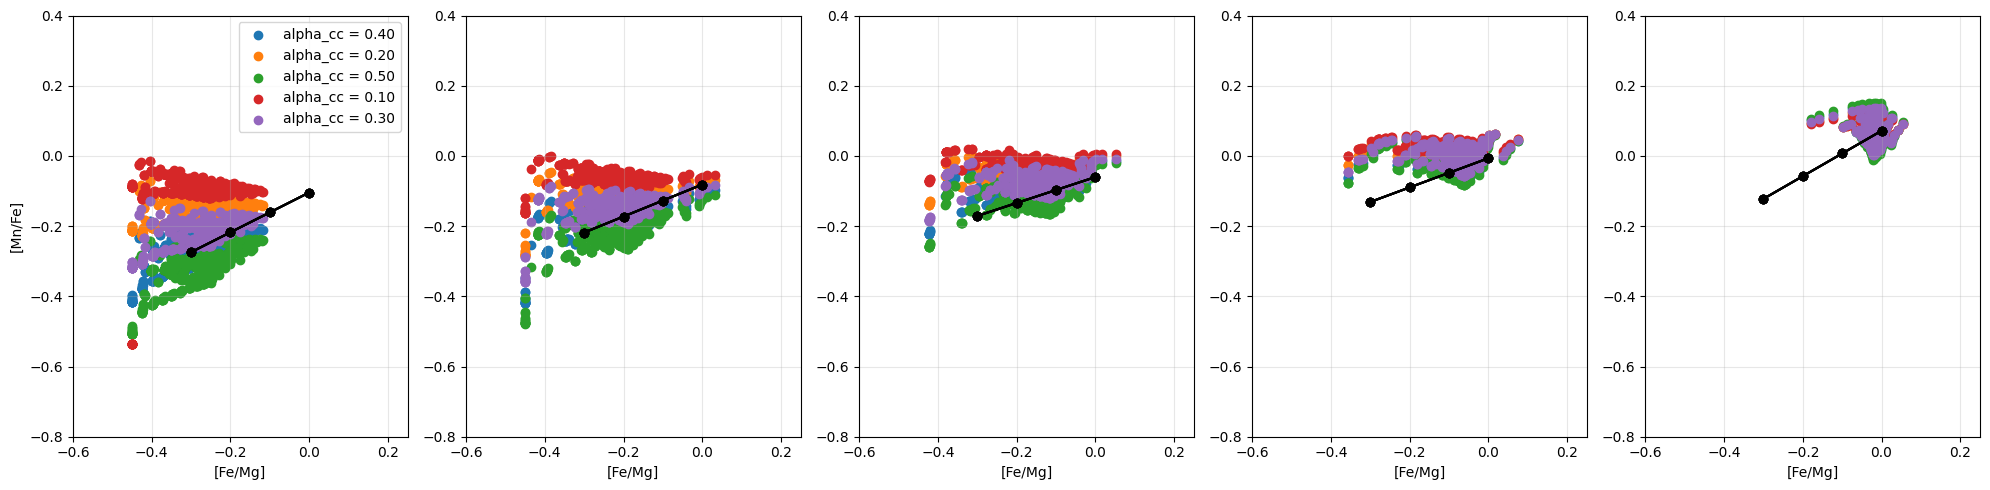

In [32]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

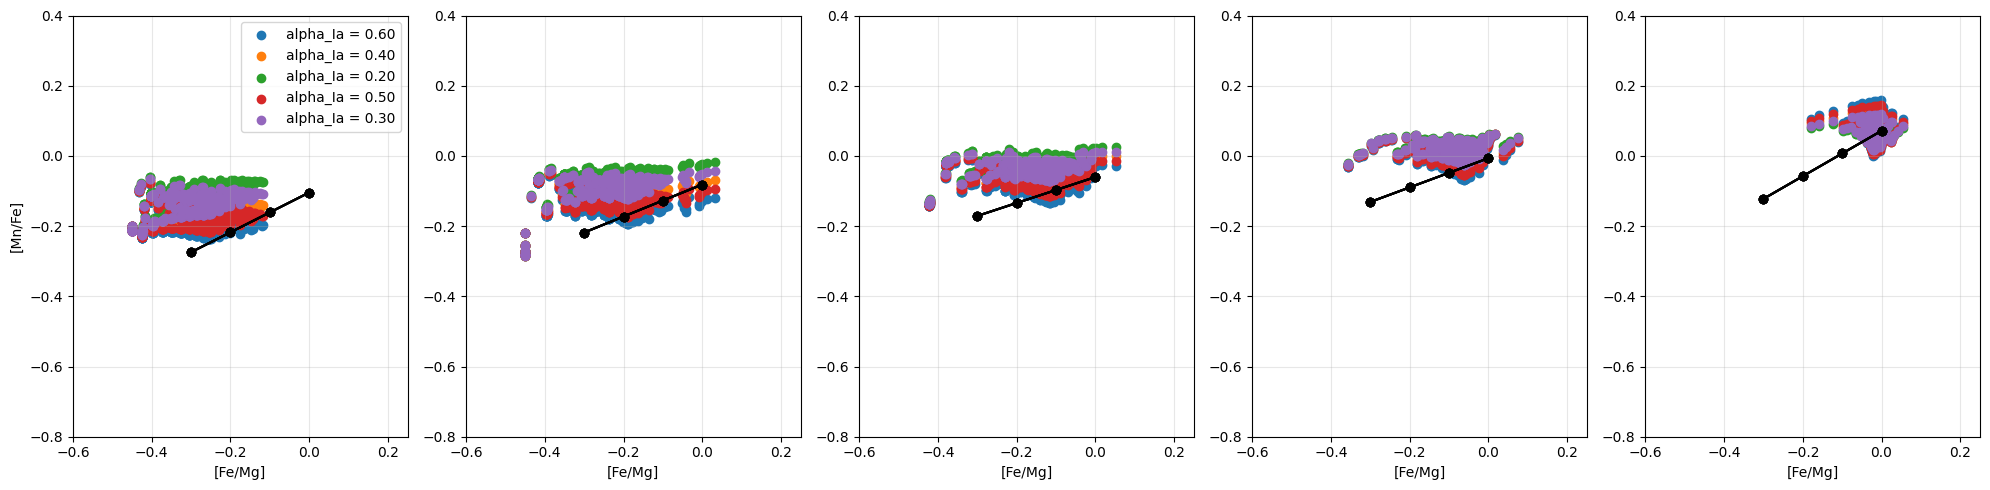

In [33]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter0") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

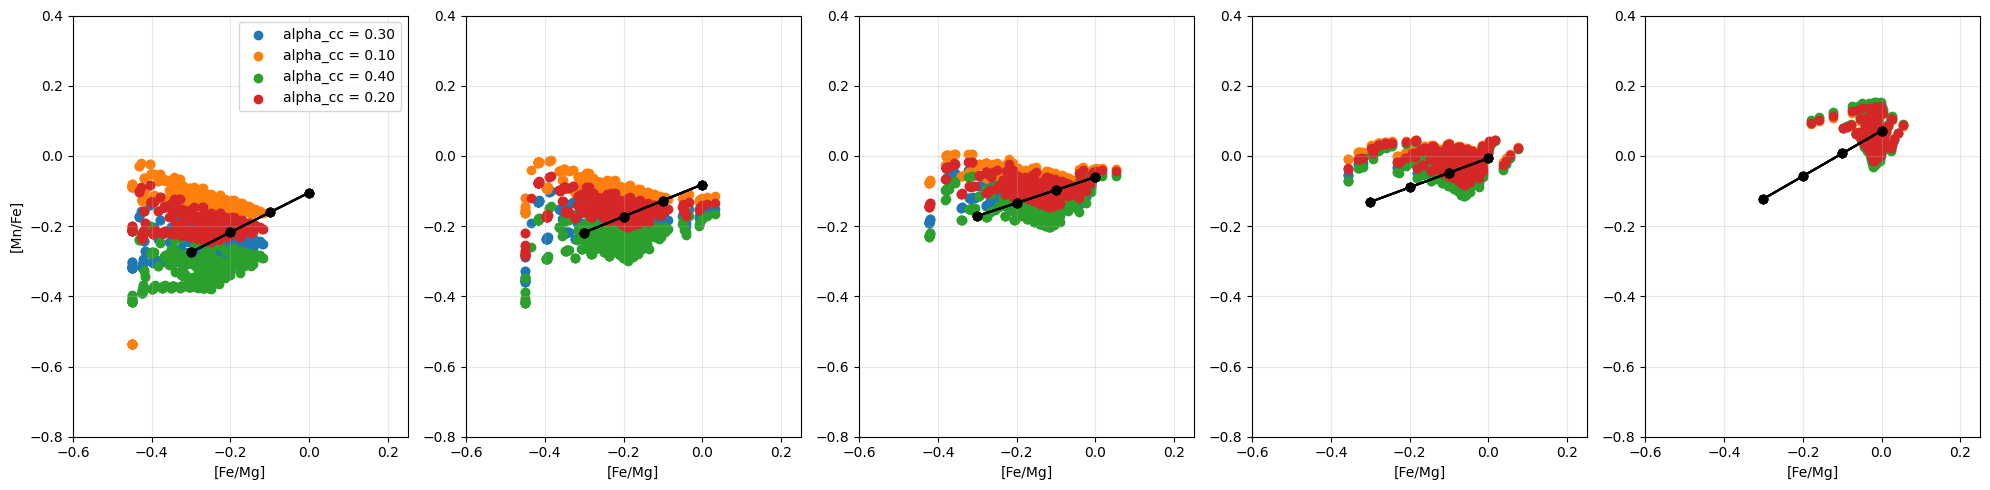

In [34]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_cc_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_cc = {model_subset['alpha_cc'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

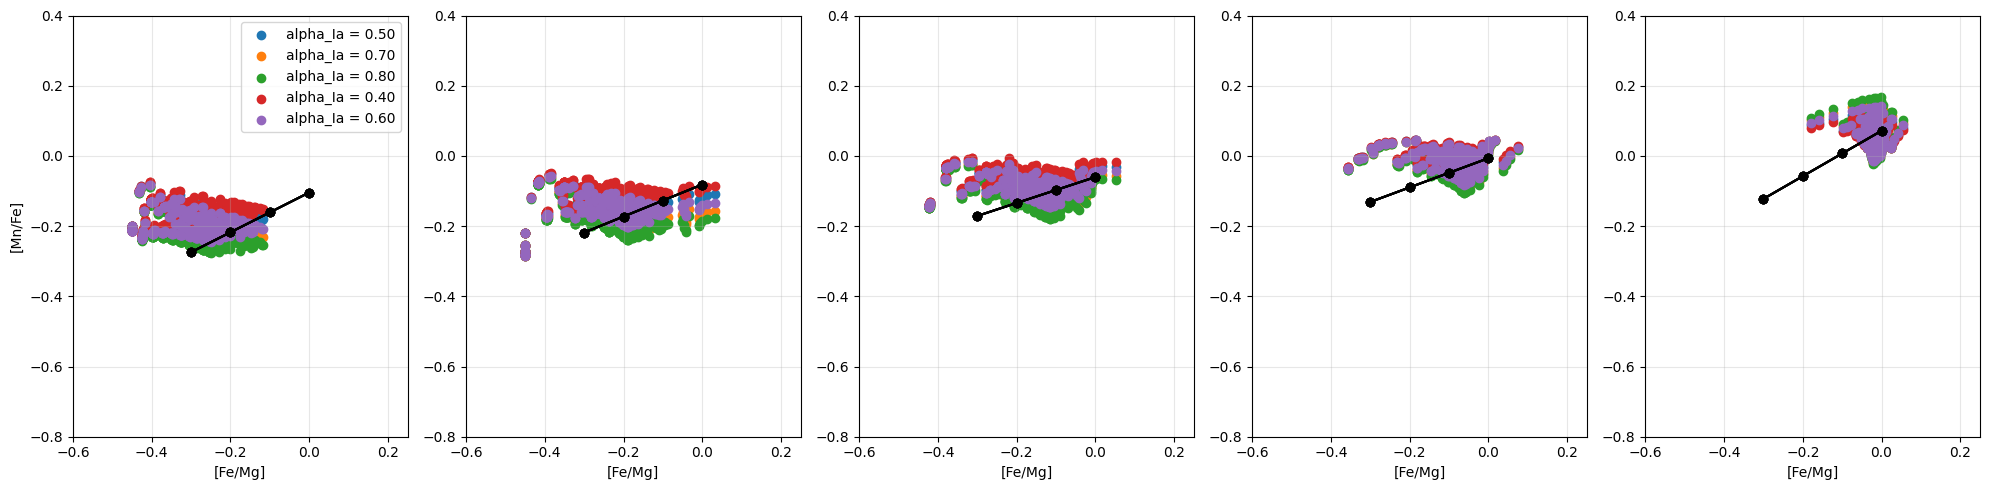

In [35]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter1") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()

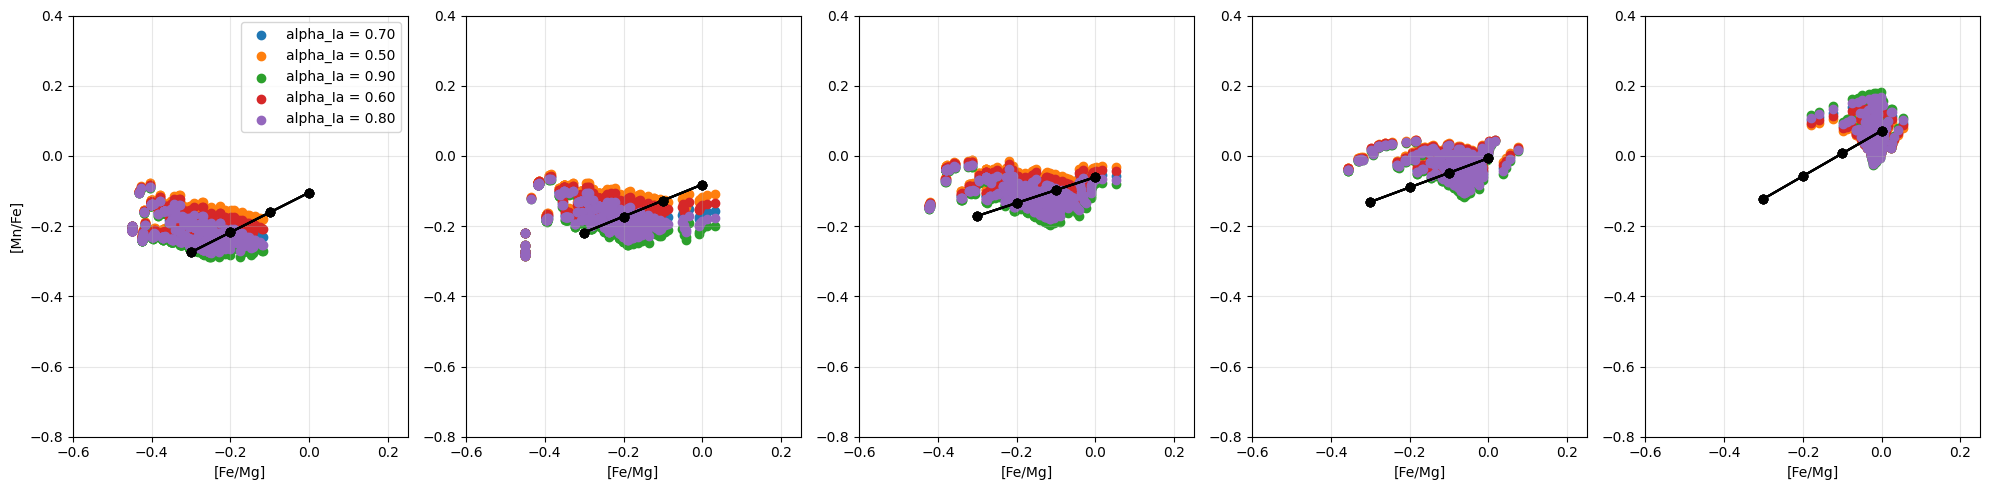

In [36]:
filepath_list = []
output_dfs = []

for filename in os.listdir(folder_path):
    if filename.startswith("alpha_Ia_iter4") and filename.endswith(".csv"):
        filepath_list.append(folder_path+filename)
        df = pd.read_csv(folder_path+filename)
        output_dfs.append(df)


plt.figure(figsize=(20,5))

for i in range(len(output_dfs)):
    model_df = output_dfs[i]
    mg_h_bins = model_df['mg_h_bin'].unique()
    for j in range(len(mg_h_bins)):
        mg_h_bin = mg_h_bins[j]
        model_subset = model_df[np.isclose(model_df['mg_h_bin'], mg_h_bin)]
        data_subset = data[np.isclose(data['mg_h_bin_center'], mg_h_bin)]
        data_line_xs = fe_mg_centers
        data_line_ys = data_subset['slope_mn_fe'].iloc[0] * fe_mg_centers + data_subset['intercept_mn_fe'].iloc[0]
        plt.subplot(1,5,j+1)
        plt.plot(data_line_xs, data_line_ys, marker = 'o', color = 'black')
        plt.scatter(model_subset['fe_mg'], model_subset['mn_fe'], label = f'alpha_Ia = {model_subset['alpha_Ia'].iloc[0]:.2f}')
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.grid(True, alpha = 0.3)
        plt.xlabel("[Fe/Mg]")
        if j == 0:
            plt.ylabel("[Mn/Fe]")
            plt.legend()

plt.tight_layout()
plt.show()